# Seasonal Agriculture Performance Analysis
**VOIS AICTE Major Project — Batch 1, 2026-2027**

Student: Kartik Soni
College: Government Engineering College, Bikaner

This notebook looks at how farm performance (yield, profit, water use, disease risk)
changes across India's three growing seasons — **Kharif, Rabi and Zaid** — using a
dataset of 4,000 farm records across 8 states and 8 crops.

The goal isn't just to describe the data, but to find *why* the seasons behave
differently and give a few practical takeaways at the end.

## 1. Setup

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# keep the plots consistent with the presentation theme (blue/teal/green)
sns.set_style("whitegrid")
PALETTE = ["#2E83C3", "#42D0A2", "#96D141"]
sns.set_palette(PALETTE)
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 13
plt.rcParams["axes.titleweight"] = "bold"

pd.set_option("display.max_columns", None)

## 2. Loading the data

Just a first look — how big is it, what columns do we have, what do a few rows
actually look like.

In [17]:
df = pd.read_csv(r"D:\MACHINE LEARNING\Major Project\seasonal_agriculture_performance_dataset (3).csv")
print("Shape:", df.shape)
df.head()

Shape: (4000, 28)


,Farm_ID,State,District,Crop,Season,Farm_Area_Hectares,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Sunlight_Hours_Day,Soil_pH,Soil_Moisture_pct,Nitrogen_kg_ha,Phosphorus_kg_ha,Potassium_kg_ha,Irrigation_Method,Fertilizer_kg_ha,Pesticide_Litre_ha,Seed_Quality_Score,Yield_Tonnes_Ha,Production_Tonnes,Market_Price_INR_Tonne,Total_Cost_INR,Revenue_INR,Profit_INR,Water_Used_m3,Water_Efficiency_t_per_1000m3,Disease_Pest_Risk_pct
0,SF10001,Andhra Pradesh,Rajkot,Wheat,Kharif,0.53,486.4,24.3,69.1,5.8,7.14,32.8,75.8,61.3,91.0,Drip,242.7,4.33,0.76,2.46,1.30,23700,42662,30810,-11852,237,5.485,55.3
1,SF10002,Maharashtra,Nalgonda,Maize,Kharif,6.53,855.4,25.7,78.4,5.1,5.20,32.0,82.1,35.4,121.8,Flood,271.4,6.86,0.94,0.30,1.96,20613,492351,40401,-451950,4953,0.396,49.9
2,SF10003,Telangana,Warangal,Pulses,Rabi,4.86,455.6,23.9,56.4,10.3,5.82,8.1,118.5,51.5,117.9,Drip,162.6,6.08,0.98,0.52,2.53,75283,315210,190466,-124744,1275,1.984,33.7
3,SF10004,Telangana,Indore,Rice,Kharif,4.50,753.2,29.7,65.2,6.3,5.98,23.7,138.6,55.6,115.5,Rainfed,182.2,6.39,0.74,1.84,8.28,24244,296444,200740,-95704,3834,2.160,50.6
4,SF10005,Karnataka,Ludhiana,Maize,Zaid,4.21,101.6,34.1,55.2,6.5,6.90,29.3,124.1,69.0,121.4,Flood,244.9,7.61,0.90,2.21,9.30,20818,337959,193607,-144352,3287,2.829,32.3


In [18]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 28 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Farm_ID                        4000 non-null   str    
 1   State                          4000 non-null   str    
 2   District                       4000 non-null   str    
 3   Crop                           4000 non-null   str    
 4   Season                         4000 non-null   str    
 5   Farm_Area_Hectares             4000 non-null   float64
 6   Rainfall_mm                    3952 non-null   float64
 7   Avg_Temperature_C              4000 non-null   float64
 8   Humidity_pct                   4000 non-null   float64
 9   Sunlight_Hours_Day             4000 non-null   float64
 10  Soil_pH                        4000 non-null   float64
 11  Soil_Moisture_pct              3960 non-null   float64
 12  Nitrogen_kg_ha                 4000 non-null   float64
 13 

In [19]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Farm_Area_Hectares,4000.0,7.888265,4.223764,0.500,4.260,7.8950,11.65000,15.00
Rainfall_mm,3952.0,601.152657,288.925025,80.000,370.200,582.0000,834.95000,1395.20
Avg_Temperature_C,4000.0,26.818900,3.818180,16.200,23.900,26.9000,29.60000,39.70
Humidity_pct,4000.0,63.210500,11.960834,25.000,54.775,63.0000,71.90000,95.00
Sunlight_Hours_Day,4000.0,7.323050,1.121186,3.500,6.600,7.3000,8.10000,11.00
Soil_pH,4000.0,6.701010,0.641461,5.200,6.260,6.6900,7.14000,8.40
Soil_Moisture_pct,3960.0,26.508232,6.712484,8.000,21.700,26.4000,31.30000,47.00
Nitrogen_kg_ha,4000.0,120.250825,31.216452,40.000,98.500,120.1000,141.22500,220.00
Phosphorus_kg_ha,4000.0,57.781850,17.015074,15.000,46.200,57.5000,69.40000,120.00
Potassium_kg_ha,4000.0,104.760050,27.742681,30.000,86.200,105.1000,123.60000,200.00


## 3. Understanding the columns

Quick categorical check — what seasons, states and crops are actually in the data,
and whether Farm_ID is really a unique identifier.

In [20]:
print("Seasons:", df["Season"].unique())
print("States :", df["State"].unique())
print("Crops  :", df["Crop"].unique())
print("Irrigation methods:", df["Irrigation_Method"].unique())
print("\nDuplicate Farm_IDs:", df["Farm_ID"].duplicated().sum())
print("Fully duplicate rows:", df.duplicated().sum())

Seasons: <ArrowStringArray>
['Kharif', 'Rabi', 'Zaid']
Length: 3, dtype: str
States : <ArrowStringArray>
['Andhra Pradesh',    'Maharashtra',      'Telangana',      'Karnataka',
        'Gujarat',     'Tamil Nadu',         'Punjab', 'Madhya Pradesh']
Length: 8, dtype: str
Crops  : <ArrowStringArray>
[    'Wheat',     'Maize',    'Pulses',      'Rice',    'Cotton',    'Chilli',
 'Groundnut', 'Sugarcane']
Length: 8, dtype: str
Irrigation methods: <ArrowStringArray>
['Drip', 'Flood', 'Rainfed', 'Sprinkler']
Length: 4, dtype: str

Duplicate Farm_IDs: 0
Fully duplicate rows: 0


In [21]:
df["Season"].value_counts()

Season
Kharif    1779
Rabi      1627
Zaid       594
Name: count, dtype: int64

## 4. Data cleaning

`df.info()` shows three columns with missing values: `Rainfall_mm`, `Soil_Moisture_pct`
and `Yield_Tonnes_Ha`. Everything else is complete and there are no duplicate rows,
so cleaning here is really just about filling those three gaps sensibly.

Instead of a blanket mean/median fill, it makes more sense to fill each column using
a group that it actually depends on:

- **Rainfall** depends on the state and the season (a Punjab Rabi season doesn't get
  the same rain as a Kerala-style Kharif season) → fill using the (State, Season) median.
- **Soil moisture** mainly tracks the season → fill using the Season median.
- **Yield** depends heavily on the crop (sugarcane yields are on a totally different
  scale to pulses) → fill using the Crop median.

This keeps the imputed values realistic instead of dragging everything toward one
global average.

In [22]:
print("Missing values before cleaning:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Missing values before cleaning:
Rainfall_mm          48
Soil_Moisture_pct    40
Yield_Tonnes_Ha      32
dtype: int64


In [23]:
df["Rainfall_mm"] = df.groupby(["State", "Season"])["Rainfall_mm"] \
                            .transform(lambda x: x.fillna(x.median()))

df["Soil_Moisture_pct"] = df.groupby("Season")["Soil_Moisture_pct"] \
                              .transform(lambda x: x.fillna(x.median()))

df["Yield_Tonnes_Ha"] = df.groupby("Crop")["Yield_Tonnes_Ha"] \
                            .transform(lambda x: x.fillna(x.median()))

print("Missing values after cleaning:", df.isnull().sum().sum())

Missing values after cleaning: 0


## 5. A couple of new columns

Two small features that make the later comparisons easier to read:

- **Profit_Margin_pct** — profit as a percentage of revenue. Easier to compare across
  crops than raw rupee profit, since crops operate at very different scales.
- **Loss_Making** — a simple flag for whether a farm actually lost money, used to
  calculate "% of farms running at a loss" per season.

In [24]:
df["Profit_Margin_pct"] = (df["Profit_INR"] / df["Revenue_INR"]) * 100
df["Loss_Making"] = df["Profit_INR"] < 0

df[["Profit_INR", "Revenue_INR", "Profit_Margin_pct", "Loss_Making"]].head()

,Profit_INR,Revenue_INR,Profit_Margin_pct,Loss_Making
0,-11852,30810,-38.468030,True
1,-451950,40401,-1118.660429,True
2,-124744,190466,-65.494104,True
3,-95704,200740,-47.675600,True
4,-144352,193607,-74.559288,True


## 6. Season-wise overview

Before making any charts, a plain groupby gives a first sense of how the three
seasons differ.

In [25]:
season_summary = df.groupby("Season")[[
    "Rainfall_mm", "Avg_Temperature_C", "Humidity_pct",
    "Yield_Tonnes_Ha", "Water_Efficiency_t_per_1000m3",
    "Profit_INR", "Disease_Pest_Risk_pct"
]].mean().round(2)

season_summary = season_summary.reindex(["Kharif", "Rabi", "Zaid"])
season_summary

,Rainfall_mm,Avg_Temperature_C,Humidity_pct,Yield_Tonnes_Ha,Water_Efficiency_t_per_1000m3,Profit_INR,Disease_Pest_Risk_pct
Season,,,,,,,
Kharif,852.11,28.45,71.81,5.63,5.89,178914.65,54.47
Rabi,435.93,23.49,57.89,5.10,5.19,87689.47,40.48
Zaid,299.34,31.04,52.01,4.64,4.41,-24804.82,38.22


Kharif looks the wettest and most profitable, Zaid the driest, hottest and the
only season with a **negative** average profit. Rabi sits in between. The rest of the
notebook digs into why.

## 7. Chart 1 — Environmental conditions by season

Rainfall, temperature and humidity side by side, since these three largely define
what "season" even means agriculturally.

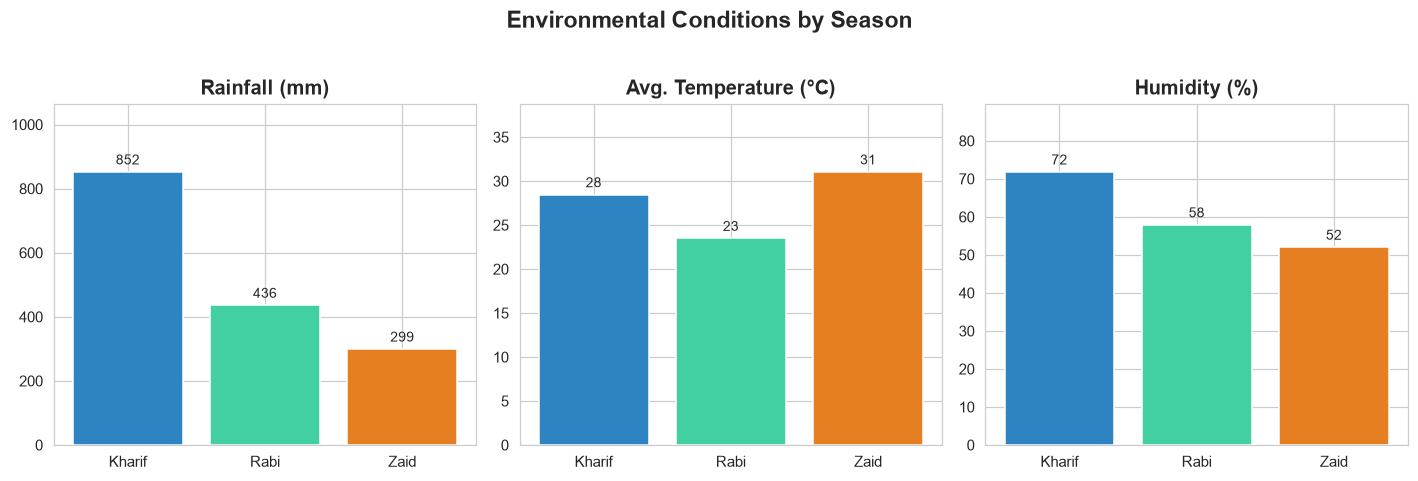

In [26]:
season_order = ["Kharif", "Rabi", "Zaid"]
colors = {"Kharif": "#2E83C3", "Rabi": "#42D0A2", "Zaid": "#E67E22"}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))

metrics = [("Rainfall_mm", "Rainfall (mm)"),
           ("Avg_Temperature_C", "Avg. Temperature (°C)"),
           ("Humidity_pct", "Humidity (%)")]

for ax, (col, label) in zip(axes, metrics):
    means = df.groupby("Season")[col].mean().reindex(season_order)
    bars = ax.bar(season_order, means, color=[colors[s] for s in season_order])
    ax.set_title(label)
    ax.bar_label(bars, fmt="%.0f", padding=3, fontsize=9)
    ax.set_ylim(0, means.max() * 1.25)

fig.suptitle("Environmental Conditions by Season", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()

plt.show()

Kharif (the monsoon season) brings almost double the rainfall of Rabi and nearly
three times that of Zaid, along with higher humidity. Zaid is the hot, dry season —
lowest rainfall, highest temperature. This is expected, but it's the baseline for
everything that follows.

## 8. Chart 2 — Yield and profit by season

Two separate plots on purpose — yield (tonnes/hectare) and profit (₹) are on
completely different scales, so a shared axis would flatten one of them.

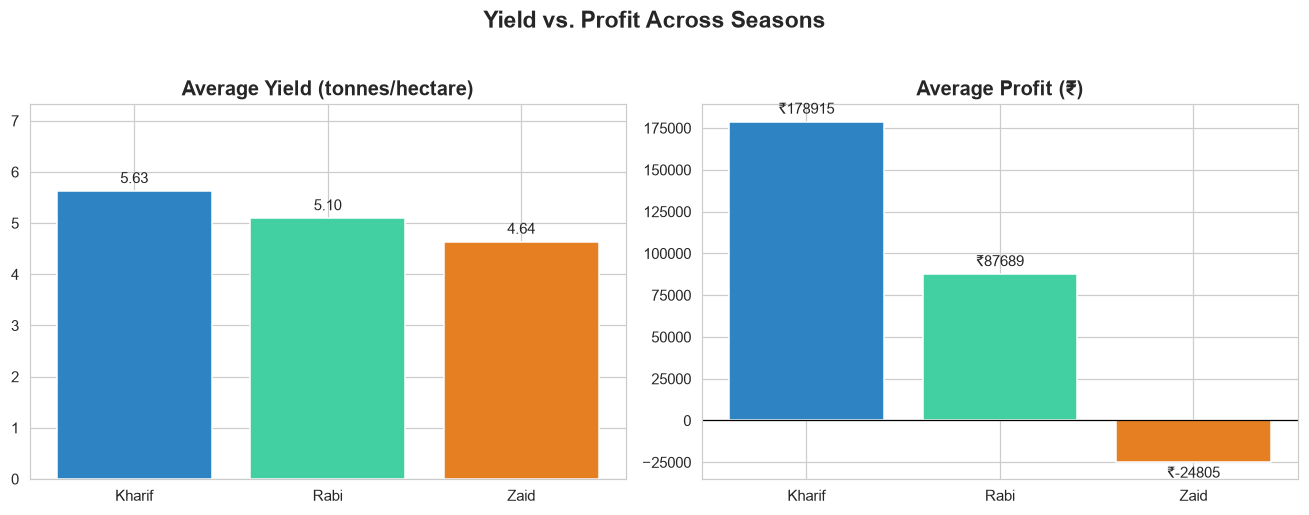

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

yield_means = df.groupby("Season")["Yield_Tonnes_Ha"].mean().reindex(season_order)
bars1 = axes[0].bar(season_order, yield_means, color=[colors[s] for s in season_order])
axes[0].set_title("Average Yield (tonnes/hectare)")
axes[0].bar_label(bars1, fmt="%.2f", padding=3)
axes[0].set_ylim(0, yield_means.max() * 1.3)

profit_means = df.groupby("Season")["Profit_INR"].mean().reindex(season_order)
bars2 = axes[1].bar(season_order, profit_means, color=[colors[s] for s in season_order])
axes[1].set_title("Average Profit (₹)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].bar_label(bars2, fmt="₹%.0f", padding=3)

fig.suptitle("Yield vs. Profit Across Seasons", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()

plt.show()

Yield drops only mildly from Kharif to Zaid (5.64 → 4.67 t/ha), but profit falls
off a cliff — from about ₹1.79 lakh down to **negative** ₹24,800. That gap between a
small yield drop and a huge profit drop is the first sign that yield alone doesn't
explain profitability. A quick statistical check below confirms this.

## 9. Is the seasonal difference statistically real?

A one-way ANOVA checks whether the season-to-season differences in profit and yield
are bigger than what random farm-to-farm variation would produce on its own.

In [28]:
groups_profit = [df[df["Season"] == s]["Profit_INR"] for s in season_order]
f_profit, p_profit = stats.f_oneway(*groups_profit)

groups_yield = [df[df["Season"] == s]["Yield_Tonnes_Ha"] for s in season_order]
f_yield, p_yield = stats.f_oneway(*groups_yield)

print(f"Profit ANOVA -> F = {f_profit:.2f}, p = {p_profit:.5f}")
print(f"Yield  ANOVA -> F = {f_yield:.2f}, p = {p_yield:.5f}")

Profit ANOVA -> F = 34.29, p = 0.00000
Yield  ANOVA -> F = 1.44, p = 0.23686


**Profit differs significantly across seasons (p < 0.001)** — this is a real,
non-random pattern. But **yield does not differ significantly across seasons
(p = 0.23)**. In other words, the season doesn't change how much farmers *grow* nearly
as much as it changes how much they *earn*. Something other than yield — most likely
disease/pest pressure and cost/price dynamics — is driving the profit swing. That's
worth digging into next.

## 10. Chart 3 — Who's actually losing money?

Averages can hide a lot. A boxplot shows the spread of profit within each season,
and a simple bar shows what share of farms are outright loss-making.

C:\Users\karti\AppData\Local\Temp\ipykernel_24288\1228247953.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Season", y="Profit_INR", order=season_order,


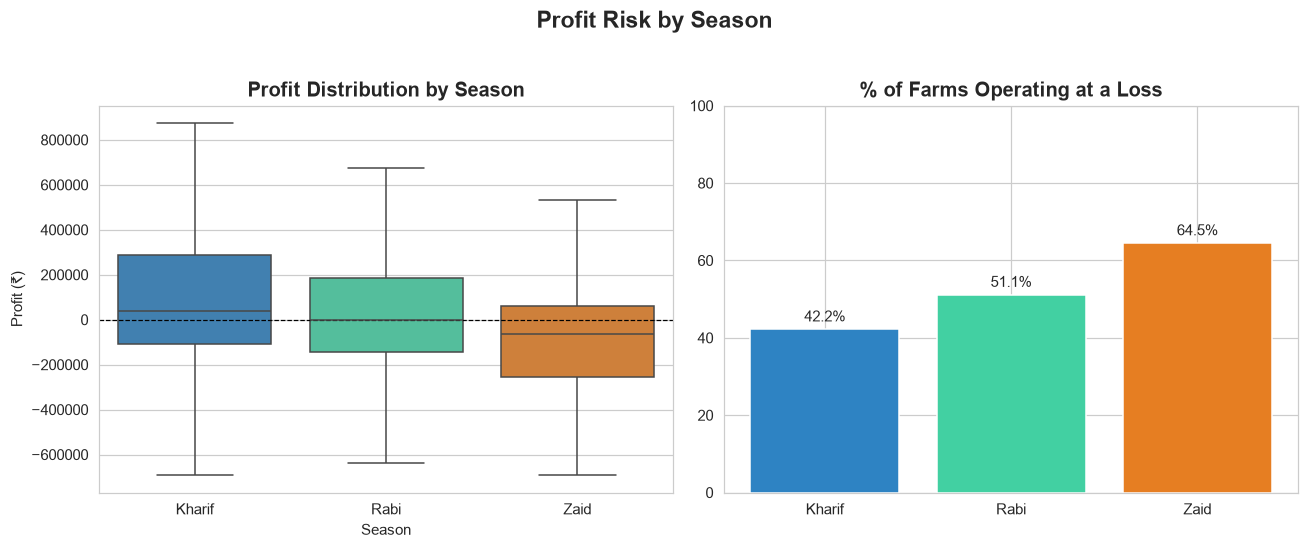

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.8))

sns.boxplot(data=df, x="Season", y="Profit_INR", order=season_order,
            palette=colors, ax=axes[0], showfliers=False)
axes[0].axhline(0, color="black", linewidth=0.8, linestyle="--")
axes[0].set_title("Profit Distribution by Season")
axes[0].set_ylabel("Profit (₹)")

loss_pct = df.groupby("Season")["Loss_Making"].mean().reindex(season_order) * 100
bars = axes[1].bar(season_order, loss_pct, color=[colors[s] for s in season_order])
axes[1].bar_label(bars, fmt="%.1f%%", padding=3)
axes[1].set_title("% of Farms Operating at a Loss")
axes[1].set_ylim(0, 100)

fig.suptitle("Profit Risk by Season", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()

plt.show()

This is probably the single most important chart in the whole analysis.
**64.5% of Zaid-season farms lose money**, compared to 51.1% in Rabi and 42.2% in
Kharif. Zaid isn't just the least profitable season on average — for the majority of
farmers growing in it, it's a losing proposition.

## 11. Chart 4 — Disease and pest pressure

Kharif had the highest average profit *and* the highest disease/pest risk score.
Worth checking what's actually driving that risk.

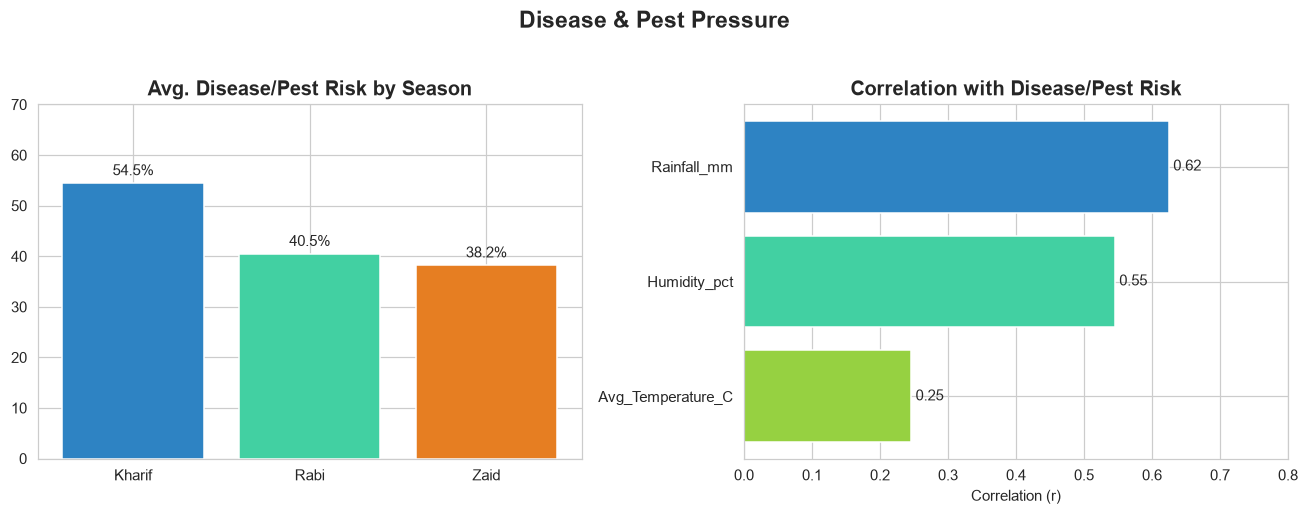

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

risk_means = df.groupby("Season")["Disease_Pest_Risk_pct"].mean().reindex(season_order)
bars = axes[0].bar(season_order, risk_means, color=[colors[s] for s in season_order])
axes[0].bar_label(bars, fmt="%.1f%%", padding=3)
axes[0].set_title("Avg. Disease/Pest Risk by Season")
axes[0].set_ylim(0, 70)

risk_corr = df[["Rainfall_mm", "Humidity_pct", "Avg_Temperature_C"]].corrwith(df["Disease_Pest_Risk_pct"]).sort_values()
bar_colors = ["#96D141", "#42D0A2", "#2E83C3"]
bars2 = axes[1].barh(risk_corr.index, risk_corr.values, color=bar_colors)
axes[1].bar_label(bars2, fmt="%.2f", padding=3)
axes[1].set_xlim(0, 0.8)
axes[1].set_title("Correlation with Disease/Pest Risk")
axes[1].set_xlabel("Correlation (r)")

fig.suptitle("Disease & Pest Pressure", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()

plt.show()

Disease/pest risk correlates fairly strongly with **rainfall (r = 0.63)** and
**humidity (r = 0.55)** — the same wet conditions that make Kharif productive also
make it the season most exposed to disease and pest pressure. Kharif's high profit
happens *despite* this risk, not because it's absent — which also hints at why Kharif
isn't dramatically more profitable than Rabi even with far better growing conditions.

## 12. Chart 5 — Does irrigation method matter?

`Irrigation_Method` has four categories: Drip, Flood, Rainfed and Sprinkler.
Checking water efficiency and profit for each.

In [31]:
irrigation_summary = df.groupby("Irrigation_Method")[
    ["Water_Used_m3", "Water_Efficiency_t_per_1000m3", "Profit_INR"]
].mean().round(2).sort_values("Profit_INR", ascending=False)

irrigation_summary

,Water_Used_m3,Water_Efficiency_t_per_1000m3,Profit_INR
Irrigation_Method,,,
Drip,5918.75,6.27,219626.00
Sprinkler,6208.26,4.67,91121.08
Rainfed,3549.55,7.56,79050.37
Flood,8026.47,3.44,73354.02


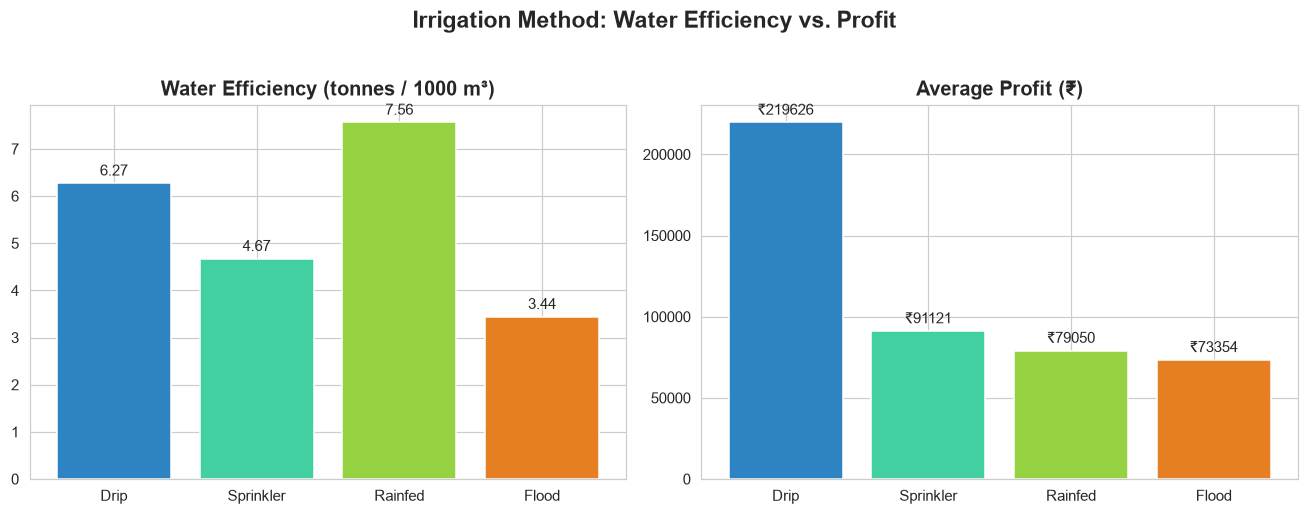

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
irr_order = irrigation_summary.index.tolist()
irr_colors = ["#2E83C3", "#42D0A2", "#96D141", "#E67E22"]

bars1 = axes[0].bar(irr_order, irrigation_summary["Water_Efficiency_t_per_1000m3"], color=irr_colors)
axes[0].bar_label(bars1, fmt="%.2f", padding=3)
axes[0].set_title("Water Efficiency (tonnes / 1000 m³)")

bars2 = axes[1].bar(irr_order, irrigation_summary["Profit_INR"], color=irr_colors)
axes[1].bar_label(bars2, fmt="₹%.0f", padding=3)
axes[1].set_title("Average Profit (₹)")

fig.suptitle("Irrigation Method: Water Efficiency vs. Profit", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()

plt.show()

**Drip irrigation is the clear winner** — almost double the water efficiency of
Flood irrigation and roughly **3x its average profit** (₹2.20 lakh vs ₹0.73 lakh).
Flood irrigation uses the most water for one of the lowest returns. This holds in
every season, not just on average — Drip and Rainfed consistently beat Flood and
Sprinkler across Kharif, Rabi and Zaid alike.

## 13. Chart 6 — Correlation heatmap

A broader look at which numeric variables actually move together.

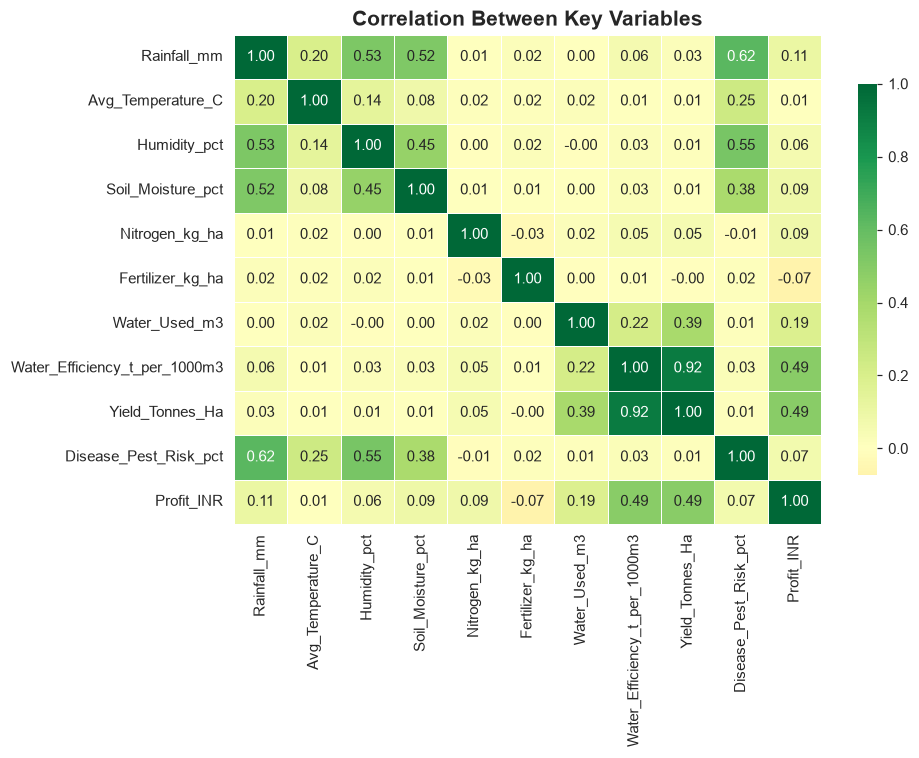

In [33]:
num_cols = ["Rainfall_mm", "Avg_Temperature_C", "Humidity_pct", "Soil_Moisture_pct",
            "Nitrogen_kg_ha", "Fertilizer_kg_ha", "Water_Used_m3",
            "Water_Efficiency_t_per_1000m3", "Yield_Tonnes_Ha",
            "Disease_Pest_Risk_pct", "Profit_INR"]

plt.figure(figsize=(9, 7))
corr = df[num_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdYlGn", center=0,
            linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Correlation Between Key Variables", fontweight="bold", fontsize=14)
plt.tight_layout()

plt.show()

**Water efficiency is by far the strongest driver of yield (r = 0.91)** — much
stronger than fertilizer, rainfall or any single nutrient. Yield in turn correlates
with profit at r = 0.49. Interestingly, raw rainfall barely correlates with yield at
all in this full-dataset view (r ≈ 0.03) — which looks odd at first, so it's worth
checking more carefully.

## 14. Why does rainfall barely correlate with yield?

The dataset mixes 8 very different crops — sugarcane yields 40-100 t/ha while pulses
top out around 2 t/ha. A single aggregate correlation gets confused by this mix (a
classic Simpson's Paradox situation). Checking the rainfall-yield correlation
*within* each crop separately tells a clearer story.

In [34]:
rain_yield_by_crop = df.groupby("Crop").apply(
    lambda g: g["Rainfall_mm"].corr(g["Yield_Tonnes_Ha"])
).sort_values(ascending=False)

rain_yield_by_crop.round(3)

Crop
Sugarcane    0.270
Pulses       0.244
Cotton       0.238
Groundnut    0.233
Maize        0.217
Chilli       0.200
Rice         0.187
Wheat        0.177
dtype: float64

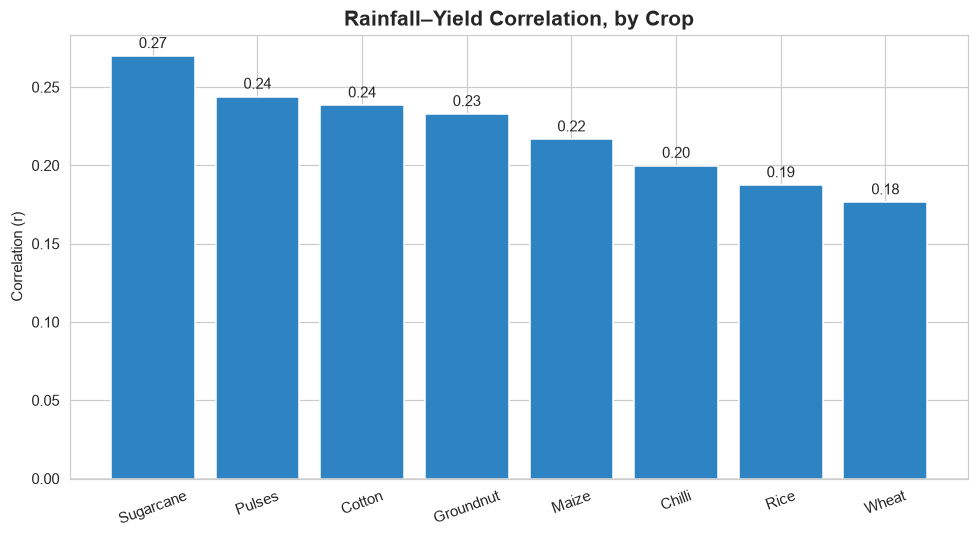

In [35]:
plt.figure(figsize=(9, 5))
bars = plt.bar(rain_yield_by_crop.index, rain_yield_by_crop.values, color="#2E83C3")
plt.bar_label(bars, fmt="%.2f", padding=3)
plt.axhline(0, color="black", linewidth=0.8)
plt.title("Rainfall–Yield Correlation, by Crop", fontweight="bold", fontsize=14)
plt.ylabel("Correlation (r)")
plt.xticks(rotation=20)
plt.tight_layout()

plt.show()

Once crop is held constant, rainfall *does* show a consistent positive
relationship with yield (r ≈ 0.18–0.28 for every crop). The near-zero aggregate
correlation wasn't a "no relationship" finding — it was crop mix hiding a real one.
**Lesson: always check relationships within a category before ruling them out on
aggregate data.**

## 15. Chart 7 — Crop profitability across seasons

Splitting crops into two groups by scale (high-value vs. lower-value) so the chart
stays readable — plotting Sugarcane next to Pulses on the same axis would flatten
everything else.

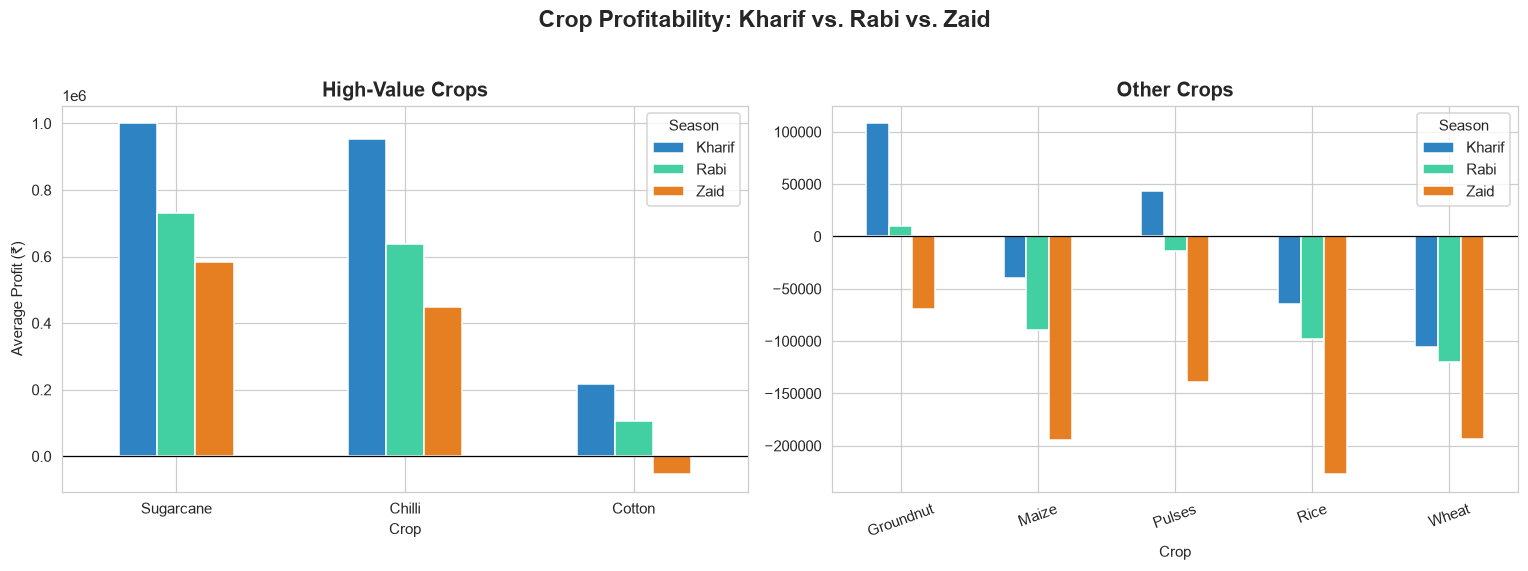

In [36]:
crop_season_profit = df.groupby(["Crop", "Season"])["Profit_INR"].mean().unstack().reindex(columns=season_order)

high_value = ["Sugarcane", "Chilli", "Cotton"]
other_crops = [c for c in crop_season_profit.index if c not in high_value]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

crop_season_profit.loc[high_value].plot(kind="bar", ax=axes[0], color=[colors[s] for s in season_order])
axes[0].set_title("High-Value Crops")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_ylabel("Average Profit (₹)")
axes[0].legend(title="Season")
axes[0].tick_params(axis="x", rotation=0)

crop_season_profit.loc[other_crops].plot(kind="bar", ax=axes[1], color=[colors[s] for s in season_order])
axes[1].set_title("Other Crops")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].legend(title="Season")
axes[1].tick_params(axis="x", rotation=20)

fig.suptitle("Crop Profitability: Kharif vs. Rabi vs. Zaid", fontsize=15, fontweight="bold", y=1.03)
plt.tight_layout()

plt.show()

**Every single one of the 8 crops is least profitable in Zaid** — this isn't
one or two crops dragging the average down, it's a pattern that holds across the
board. Rice, Wheat, Maize and Pulses are actually loss-making on average in Rabi and
Zaid, while Chilli and Sugarcane stay profitable in all three seasons but still peak
in Kharif. Zaid being the toughest season is a genuinely universal pattern in this
data, not a quirk of one crop.

## 16. Key Findings

1. **Season affects profit far more than it affects yield.** ANOVA confirms profit
   differs significantly across seasons (p < 0.001) while yield does not (p = 0.23).
   Whatever is happening season to season, it isn't mainly about how much gets grown.

2. **Zaid is the financially risky season.** Average profit is negative (–₹24,805)
   and 64.5% of Zaid farms lose money, driven by the lowest rainfall (299 mm) and
   highest average temperature (31°C) of the three seasons.

3. **Kharif is the most profitable season but also the riskiest for disease/pests**
   (54.5% average risk score), because the same rain and humidity that support strong
   growth (852 mm rainfall) also favour disease and pest pressure (r = 0.63 with
   rainfall, r = 0.55 with humidity).

4. **Water efficiency is the strongest single driver of yield** (r = 0.91) — far
   ahead of fertilizer or rainfall taken alone.

5. **Irrigation method matters more than almost anything else farmers control.**
   Drip irrigation delivers roughly 3x the average profit of Flood irrigation
   (₹2.20 lakh vs ₹0.73 lakh) with much higher water efficiency, and this advantage
   holds in every season.

6. **Rainfall does help yield — but only once you control for crop.** The aggregate
   correlation looked negligible (r ≈ 0.03) purely because the dataset mixes crops on
   very different yield scales; within any single crop, rainfall and yield move
   together positively (r ≈ 0.18–0.28).

7. **The Kharif → Rabi → Zaid profit decline is universal** — it shows up in all 8
   crops individually, not just in the aggregate average.

## 17. Recommendations

- **Treat Zaid-season cultivation as high-risk.** Farmers relying on Zaid without
  reliable irrigation are more likely than not to lose money — this is a strong
  candidate for targeted support (subsidised irrigation access, drought-resistant
  seed varieties, or crop insurance).
- **Push Drip irrigation adoption, especially in Rabi and Zaid**, where water is
  scarcer and its efficiency advantage matters most.
- **Kharif-season disease/pest monitoring deserves more resources** given its
  strong correlation with rainfall and humidity — proactive spraying schedules
  timed to monsoon intensity could protect Kharif's profit advantage.
- **Any yield-improvement analysis should control for crop type first** — the
  rainfall example shows that crop-mixed aggregates can hide (or fake) relationships
  that are perfectly real within a single crop.

## 18. Conclusion

Across 4,000 farm records, the three growing seasons behave very differently — but
not in the way a first glance suggests. Yield barely moves across seasons; profit
swings dramatically, largely driven by disease/pest pressure in Kharif and
water/heat stress in Zaid, layered on top of how efficiently each farm uses its water.
Season, in this dataset, is less a story about *how much grows* and more a story about
*how much of it survives to become profit*.